In [2]:
import numpy as np
import torch
import torchvision.models
import torch.nn as nn
import pandas as pd
import time
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent.parent))
from models.utils import set_seed, train, evaluate_model, plot_training_history, get_loaders
from models.baseline_cnn import BaselineCNN
from models.alexnet import ModifiedAlexNet

sys.path.append(str(Path().resolve().parent))
from hyperparameters.hyperparameter_plots import summarize_results, print_summary_table, plot_loss_comparison, plot_accuracy_comparison
sys.path.append(str(Path().resolve().parent.parent))
from utils import save_results

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [3]:
DATA_DIR = Path("../../data")

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [4]:
SEEDS = [0, 1, 2]
BATCH_SIZE = 256

## Transfer learning
Applied only for **ResNet** since the rest of our networks are not pretrained.

#### Fine-tuning

In [5]:
def create_resnet_model_fine_tuning():
    model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)
    return model

def test_fine_tuning(
    model,
    seeds,
    scheduler=None,
    device=None,
    num_epochs=20,
):
    results = {}
    for seed in seeds:
        print(f"\nFINE TUNING | SEED={seed}")
        set_seed(seed)

        train_loader, valid_loader, test_loader = get_loaders(
            train_dir=TRAIN_DIR,
            valid_dir=VALID_DIR,
            test_dir=TEST_DIR,
            image_size=32,
            batch_size=BATCH_SIZE,
            seed=seed,
        )

        model_instance = model()
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model_instance.parameters(), lr=1e-3)

        print("------------------------------------------------------")

        history = train(
            model_instance, 
            train_loader, 
            valid_loader, 
            criterion, 
            optimizer,
            scheduler=scheduler, 
            device=device, 
            num_epochs=num_epochs, 
            verbose=True, 
            verbose_interval=max(1, int(num_epochs/10)),
        )

        validation_accuracy = history['valid_acc'][-1]
        validation_loss = history['valid_loss'][-1]
        test_accuracy, test_loss = evaluate_model(
            model_instance, test_loader, criterion, device
        )

        results[seed] = {
            "history": history,
            "valid_acc": validation_accuracy,
            "valid_loss": validation_loss,
            "test_acc": test_accuracy,
            "test_loss": test_loss,
        }

        print("------------------------------------------------------")

        print(f"VALIDATION ACCURACY: {validation_accuracy:.4f} | TEST ACCURACY: {test_accuracy:.4f}")

        print("------------------------------------------------------")
    
    return results

In [6]:
resnet_fine_tuning_results = test_fine_tuning(
    model=create_resnet_model_fine_tuning,
    seeds=SEEDS,
    device=device,
    num_epochs=20,
)


FINE TUNING | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 0.8795 | Valid Loss: 0.9555 | Valid Acc: 0.6668
Epoch 4/20 | Train Loss: 0.6332 | Valid Loss: 0.9089 | Valid Acc: 0.6835
Epoch 6/20 | Train Loss: 0.4332 | Valid Loss: 1.0230 | Valid Acc: 0.6788
Epoch 8/20 | Train Loss: 0.2859 | Valid Loss: 1.1988 | Valid Acc: 0.6798
Epoch 10/20 | Train Loss: 0.1854 | Valid Loss: 1.3789 | Valid Acc: 0.6773
Epoch 12/20 | Train Loss: 0.1322 | Valid Loss: 1.5174 | Valid Acc: 0.6670
Epoch 14/20 | Train Loss: 0.1037 | Valid Loss: 1.5612 | Valid Acc: 0.6710
Epoch 16/20 | Train Loss: 0.0910 | Valid Loss: 1.6255 | Valid Acc: 0.6792
Epoch 18/20 | Train Loss: 0.0791 | Valid Loss: 1.6437 | Valid Acc: 0.6734
Epoch 20/20 | Train Loss: 0.0686 | Valid Loss: 1.7677 | Valid Acc: 0.6756
Best validation accuracy: 0.6844
------------------------------------------------------
VALIDATION ACCURACY: 0.6756 | TEST ACCURACY: 0.6764
-----------------------------------------------

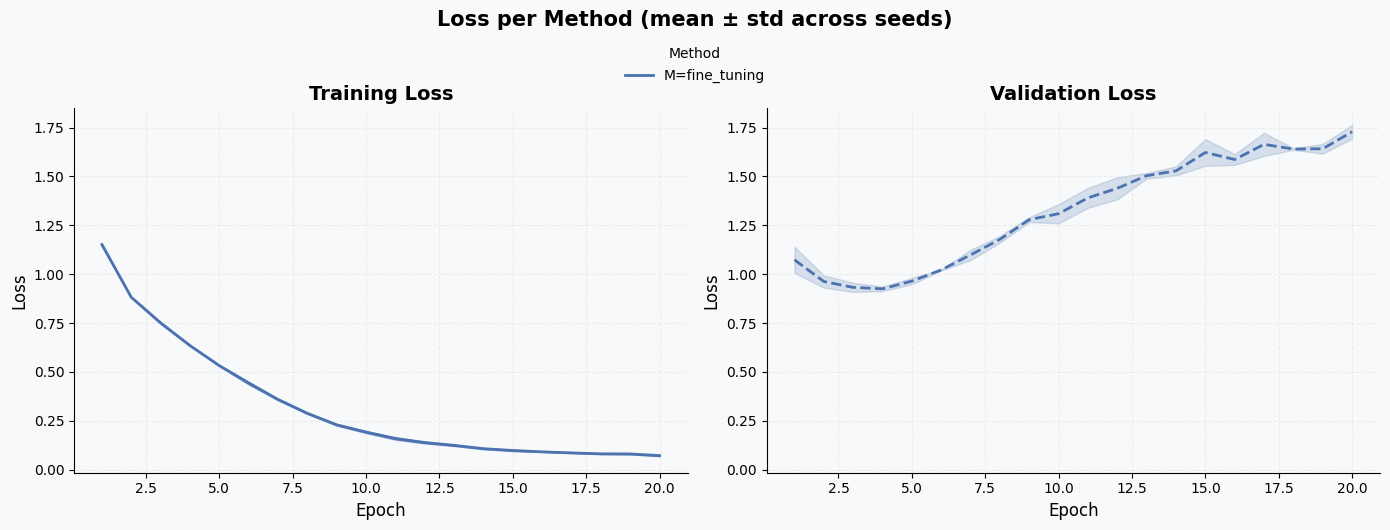

In [9]:
results_for_plot = {
    "fine_tuning": resnet_fine_tuning_results
}

plot_loss_comparison(results_for_plot, param_name="Method", param_name_short="M")

In [11]:
for aug, seed_dict in results_for_plot.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"augmentation={aug} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

augmentation=fine_tuning | seeds=3 | max std=0.006776


In [12]:
resnet_fine_tuning_df = summarize_results(
    results_for_plot,
    hyperparameter="M"
)
resnet_fine_tuning_df

,Model,M,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,fine_tuning,0.677074,0.001078,1.728899,0.035149,0.677704,0.001346,1.727819,0.040934


In [13]:
print_summary_table(resnet_fine_tuning_df, hyperparameter="M")

,Model,M,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,fine_tuning,0.6771 ± 0.0011,1.7289 ± 0.0351,0.6777 ± 0.0013,1.7278 ± 0.0409


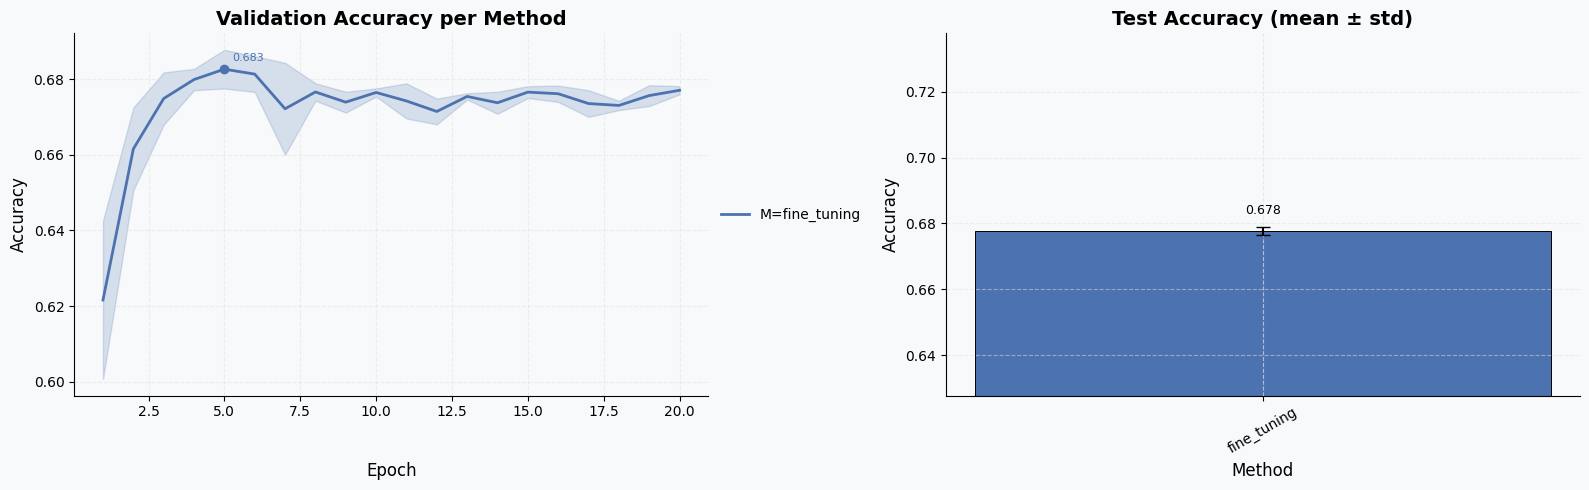

In [14]:
plot_accuracy_comparison(results_for_plot, param_name="Method", param_name_short="M")

In [15]:
save_results(results_for_plot, "fine_tuning_results_resnet")

#### Feature extraction

In [23]:
def create_resnet_model_feature_extraction():
    model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)
    return model

def test_feature_extraction(
    model,
    seeds,
    scheduler=None,
    device=None,
    num_epochs=20,
):
    results = {}
    for seed in seeds:
        print(f"\nFEATURE EXTRACTION | SEED={seed}")
        set_seed(seed)

        train_loader, valid_loader, test_loader = get_loaders(
            train_dir=TRAIN_DIR,
            valid_dir=VALID_DIR,
            test_dir=TEST_DIR,
            image_size=32,
            batch_size=BATCH_SIZE,
            seed=seed,
        )

        model_instance = model()
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model_instance.fc.parameters(), lr=1e-3)

        print("------------------------------------------------------")

        history = train(
            model_instance, 
            train_loader, 
            valid_loader, 
            criterion, 
            optimizer,
            scheduler=scheduler, 
            device=device, 
            num_epochs=num_epochs, 
            verbose=True, 
            verbose_interval=max(1, int(num_epochs/10)),
        )

        validation_accuracy = history['valid_acc'][-1]
        validation_loss = history['valid_loss'][-1]
        test_accuracy, test_loss = evaluate_model(
            model_instance, test_loader, criterion, device
        )

        results[seed] = {
            "history": history,
            "valid_acc": validation_accuracy,
            "valid_loss": validation_loss,
            "test_acc": test_accuracy,
            "test_loss": test_loss,
        }

        print("------------------------------------------------------")

        print(f"VALIDATION ACCURACY: {validation_accuracy:.4f} | TEST ACCURACY: {test_accuracy:.4f}")

        print("------------------------------------------------------")
    
    return results

In [24]:
resnet_feature_extraction_results = test_feature_extraction(
    model=create_resnet_model_feature_extraction,
    seeds=SEEDS,
    device=device,
    num_epochs=20,
)


FEATURE EXTRACTION | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.7529 | Valid Loss: 1.7632 | Valid Acc: 0.3745
Epoch 4/20 | Train Loss: 1.7235 | Valid Loss: 1.7371 | Valid Acc: 0.3842
Epoch 6/20 | Train Loss: 1.7175 | Valid Loss: 1.7440 | Valid Acc: 0.3822
Epoch 8/20 | Train Loss: 1.7129 | Valid Loss: 1.7380 | Valid Acc: 0.3862
Epoch 10/20 | Train Loss: 1.7138 | Valid Loss: 1.7374 | Valid Acc: 0.3867
Epoch 12/20 | Train Loss: 1.7115 | Valid Loss: 1.7368 | Valid Acc: 0.3877
Epoch 14/20 | Train Loss: 1.7124 | Valid Loss: 1.7299 | Valid Acc: 0.3894
Epoch 16/20 | Train Loss: 1.7113 | Valid Loss: 1.7379 | Valid Acc: 0.3858
Epoch 18/20 | Train Loss: 1.7120 | Valid Loss: 1.7386 | Valid Acc: 0.3866
Epoch 20/20 | Train Loss: 1.7105 | Valid Loss: 1.7381 | Valid Acc: 0.3875
Best validation accuracy: 0.3894
------------------------------------------------------
VALIDATION ACCURACY: 0.3875 | TEST ACCURACY: 0.3891
----------------------------------------

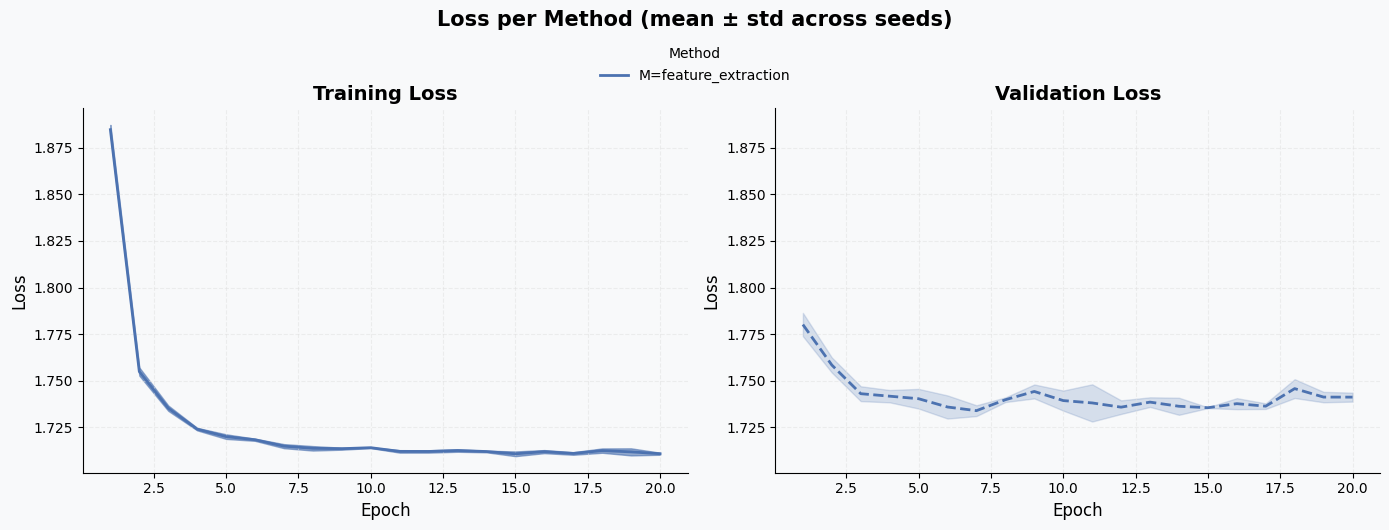

In [25]:
results_for_plot_fe = {
    "feature_extraction": resnet_feature_extraction_results
}

plot_loss_comparison(results_for_plot_fe, param_name="Method", param_name_short="M")

In [26]:
for aug, seed_dict in results_for_plot_fe.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"augmentation={aug} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

augmentation=feature_extraction | seeds=3 | max std=0.002560


In [27]:
resnet_feature_extraction_df = summarize_results(
    results_for_plot_fe,
    hyperparameter="M"
)
resnet_feature_extraction_df

,Model,M,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,feature_extraction,0.384615,0.002146,1.741124,0.002409,0.38703,0.001556,1.74048,0.00258


In [28]:
print_summary_table(resnet_feature_extraction_df, hyperparameter="M")

,Model,M,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,feature_extraction,0.3846 ± 0.0021,1.7411 ± 0.0024,0.3870 ± 0.0016,1.7405 ± 0.0026


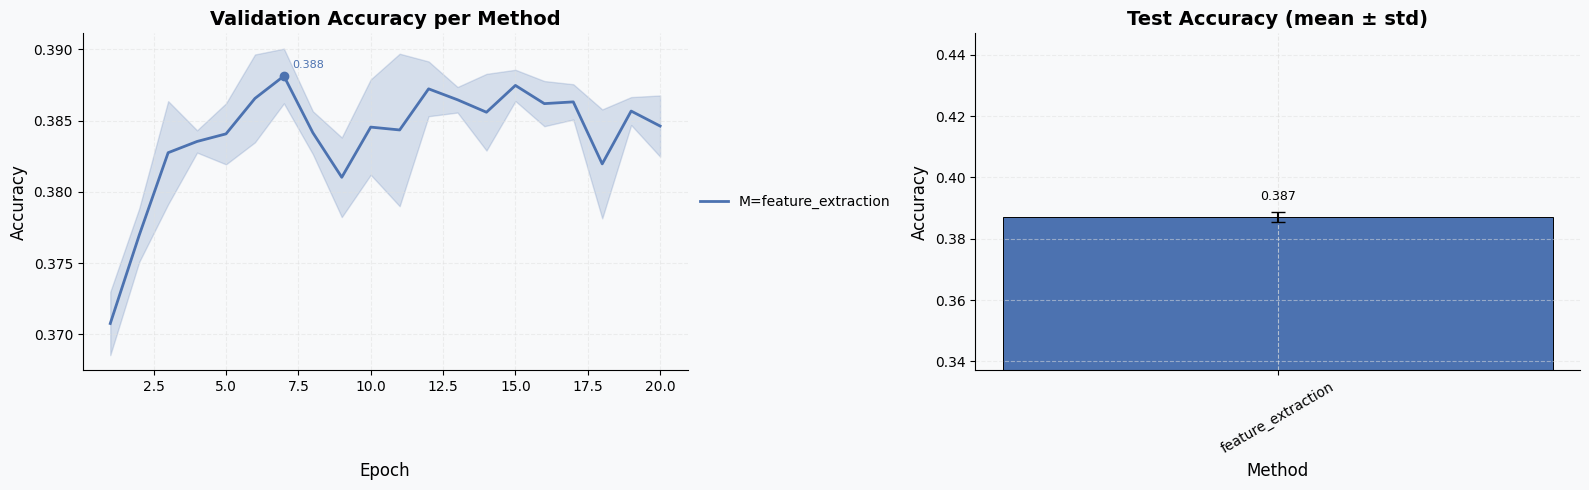

In [30]:
plot_accuracy_comparison(results_for_plot_fe, param_name="Method", param_name_short="M")

In [31]:
save_results(results_for_plot_fe, "feature_extraction_results_resnet")